## Ejercicio de Programación 1 - Simulación del Plano UV


1. Implementar las matrices de rotacion ECEF-ENU, ENU-Horizontal, Horizontal-
Ecuatorial y Ecuatorial-UVW

2. Generar posiciones de antenas para configuraciones VLA y ALMA
3. Calcular baselines entre todas las parejas de antenas
4. Aplicar la secuencia completa de transformaciones de coordenadas
5. Calcular cobertura UVW para una observacion de 6 horas
6. Visualizar la cobertura en el plano UV

In [3]:
%reload_ext autoreload
%autoreload 2

In [4]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# imports
from numba import cuda
import math
import matplotlib.pyplot as plt
# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage


/home/vcnt/y/envs/radiointerferometry-env/lib/python3.13/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


### Simulacion VLA Banda L

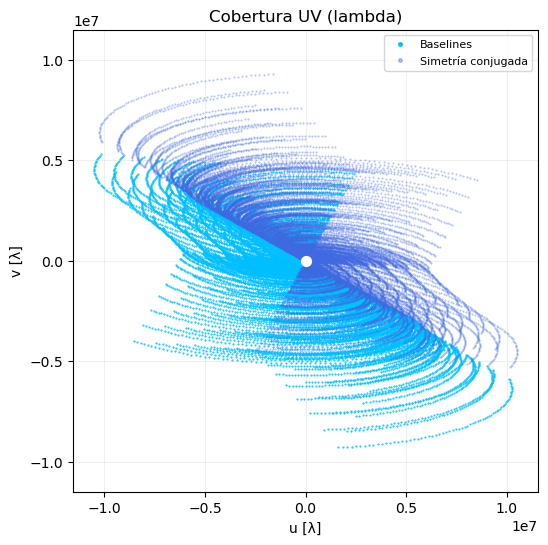

In [5]:
# simulate visibilities no grid
VLA_L_4 = {
  "latitude": 34.078749,
  "longitude": -107.617728,
  "file_route": "../antenna_arrays/vla.a.cfg",
  "catalog_source": "Sirius",
  "utc_start": "2024-10-21T00:00:00",
  "utc_end": "2024-10-21T06:00:00",
  "step_min": 5,
  "n_freqs": 4,
  "interferometer": {
    "name": "VLA",
    "band_name": "L" },
  "n_sources": 100,
  "max_offset_deg": 2,
  "flux_range": [0.1, 2.0],
  "seed": 42
  }

V, uvw, uvw_lambda, frequencies, baselines_enu, _ , _ = visibilities_simulation(VLA_L_4)

plot_uv_coverage(uvw, unit='lambda')

## Simulacion ALMA Banda 

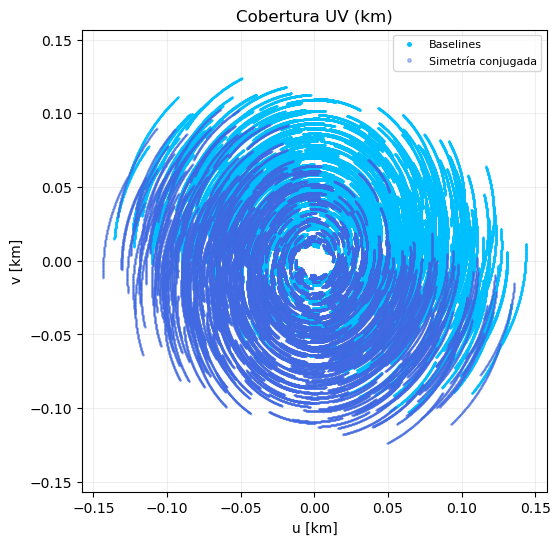

In [14]:
# simulate visibilities no grid
ALMA_1 = {
  "latitude": -23.0235, # alma coords
  "longitude": 67.7539,
  "file_route": "../antenna_arrays/alma.cycle10.1.cfg",
  "catalog_source": "LMC",
  "utc_start": "2002-10-05T00:00:00",
  "utc_end": "2002-10-05T02:00:00",
  "step_min": 0.5,
  "n_freqs": 100,
  "interferometer": {
    "name": "ALMA",
    "band_name": "Band 1" },
  "n_sources": 14,
  "max_offset_deg": 2,
  "flux_range": [0.1, 2.0],
  "seed": 42
  }

V , uvw, uvw_lambda, [frequencies, channel_bandwith] , _, sources, dir_cosines = visibilities_simulation(ALMA_1)

plot_uv_coverage(uvw, unit='km', show_symmetry=True)

## Ejercicio de Programación 2 - Simulación con cobertura UVW real

1. Implementar la ecuación de visibilidad para fuentes puntuales
2. Simular múltiples fuentes con diferentes posiciones y flujos
3. Añadir ruido térmico realista
4. Calcular y visualizar SNR vs distancia UV
5. Analizar la distribuci´on de amplitudes y fases


- 14 Fuentes puntuales

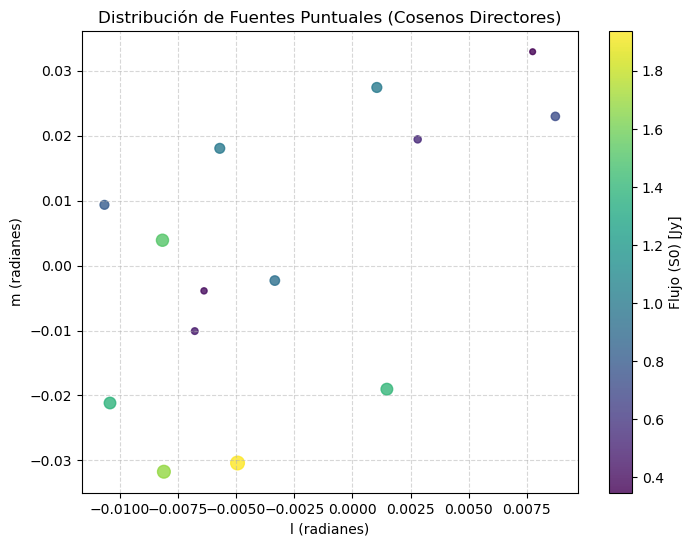

In [15]:
from modules.plots import plot_sources

plot_sources(dir_cosines[0], dir_cosines[1], sources)

Ruido térmico

In [16]:
channel_bandwith

150000000.0

In [20]:
from modules.noise import add_thermal_noise

T_sys = 35          # 50 Kelvin
delta_nu = 3.6e6      # 1 MHz de ancho de banda por canal
tau = 30           # step_min = 5 -> 300 s

V_noisy, sigma_thermal = add_thermal_noise(V, T_sys, channel_bandwith, tau)

for i, src in enumerate(sources):
    snr = src['S0'] / sigma_thermal # [cite: 221]
    print(f"Fuente {i}: Flujo {src['S0']:.2f} Jy -> SNR: {snr:.2f}")

Fuente 0: Flujo 0.39 Jy -> SNR: 0.27
Fuente 1: Flujo 1.40 Jy -> SNR: 0.97
Fuente 2: Flujo 1.52 Jy -> SNR: 1.05
Fuente 3: Flujo 1.94 Jy -> SNR: 1.35
Fuente 4: Flujo 0.72 Jy -> SNR: 0.50
Fuente 5: Flujo 0.80 Jy -> SNR: 0.56
Fuente 6: Flujo 0.99 Jy -> SNR: 0.69
Fuente 7: Flujo 0.46 Jy -> SNR: 0.32
Fuente 8: Flujo 0.35 Jy -> SNR: 0.24
Fuente 9: Flujo 1.00 Jy -> SNR: 0.70
Fuente 10: Flujo 0.53 Jy -> SNR: 0.37
Fuente 11: Flujo 1.37 Jy -> SNR: 0.95
Fuente 12: Flujo 0.93 Jy -> SNR: 0.65
Fuente 13: Flujo 1.68 Jy -> SNR: 1.17


In [13]:
sigma_thermal

np.float64(2.0817223638131956)